<a href="https://colab.research.google.com/github/umair594/Remote-internship_DS_CodeAlpha/blob/main/Emotion_Recognition_from_Speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Emotion Recognition from Speech**

# **Project Setup & Installation**

**Installing your ML toolkit**

>librosa

>tensorflow/keras

>scikit-learn

>numpy

>matplotlib

Before we write a single line of ML code, we need to set up our environment. Think of this like a chef organizing their kitchen — the right tools make everything smoother. We'll use librosa for audio processing and TensorFlow/Keras for deep learning.

# **Install all dependencies**

In [ ]:
pip install librosa tensorflow scikit-learn matplotlib seaborn

In [ ]:
pip install numpy pandas tqdm ipython

In [ ]:
pip install tensorflow-gpu

In [31]:
import os, glob, warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense,
    Dropout, BatchNormalization, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"librosa version: {librosa.__version__}")

TensorFlow version: 2.19.0
librosa version: 0.11.0


# **Understanding the RAVDESS Dataset**

What our data looks like & how to load it

**RAVDESS**

Ryerson Audio-Visual Database. 24 professional actors, 8 emotions, ~1,500 audio files. Free to download.

**8 Emotions**

Neutral, Calm, Happy, Sad, Angry, Fearful, Disgusted, Surprised — encoded in the filename

**File naming**

03-01-05-01-01-01-01.wav → Emotion code is the 3rd group (05 = angry).

**Download**

kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio — or use the Kaggle API.

# **Emotion label mapping**

In [32]:
# RAVDESS emotion labels — digit 3 in filename
EMOTIONS = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Often we simplify to 4 core emotions for better accuracy:
CORE_EMOTIONS = {'01': 'neutral', '03': 'happy', '04': 'sad', '05': 'angry'}

# **Load all audio files into a DataFrame**

In [34]:
def load_ravdess_metadata(data_path: str, use_core_only: bool = False) -> pd.DataFrame:
    """
    Scan RAVDESS folder and return a DataFrame with
    file paths and their corresponding emotion labels.
    """
    records = []
    pattern = os.path.join(data_path, "**/*.wav")

    for filepath in glob.glob(pattern, recursive=True):
        filename = os.path.basename(filepath)
        parts = filename.replace(".wav", "").split("-")

        if len(parts) < 7:
            continue  # skip malformed filenames

        emotion_code = parts[2]           # 3rd group = emotion
        actor_id     = parts[6]           # 7th group = actor

        emotion_map  = CORE_EMOTIONS if use_core_only else EMOTIONS
        if emotion_code not in emotion_map:
            continue

        records.append({
            'path'    : filepath,
            'emotion' : emotion_map[emotion_code],
            'actor'   : int(actor_id),
            'gender'  : 'male' if int(actor_id) % 2 != 0 else 'female'
        })

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} audio files")
    # Only try to access 'emotion' column if DataFrame is not empty
    if not df.empty:
        print(f"Emotions: {df['emotion'].unique()}")
    return df

# Usage:
df = load_ravdess_metadata("./ravdess_data/", use_core_only=False)
print(df.head())
print(df['emotion'].value_counts())

Loaded 2880 audio files
Emotions: ['surprised' 'disgust' 'calm' 'sad' 'angry' 'happy' 'neutral' 'fearful']
                                               path    emotion  actor gender
0  ./ravdess_data/Actor_05/03-01-08-02-01-02-05.wav  surprised      5   male
1  ./ravdess_data/Actor_05/03-01-07-02-01-02-05.wav    disgust      5   male
2  ./ravdess_data/Actor_05/03-01-08-02-02-02-05.wav  surprised      5   male
3  ./ravdess_data/Actor_05/03-01-02-01-01-02-05.wav       calm      5   male
4  ./ravdess_data/Actor_05/03-01-04-02-02-01-05.wav        sad      5   male
emotion
surprised    384
disgust      384
calm         384
sad          384
angry        384
happy        384
fearful      384
neutral      192
Name: count, dtype: int64


# **Exploring & Visualizing Audio Data**

Always understand your data before modeling
As a data scientist, always visualize before you model. Audio has unique visual representations — waveforms show amplitude over time, and spectrograms show frequency content. This step builds intuition for what "angry" vs "happy" speech actually looks like.

**Visualize waveforms & class distribution**

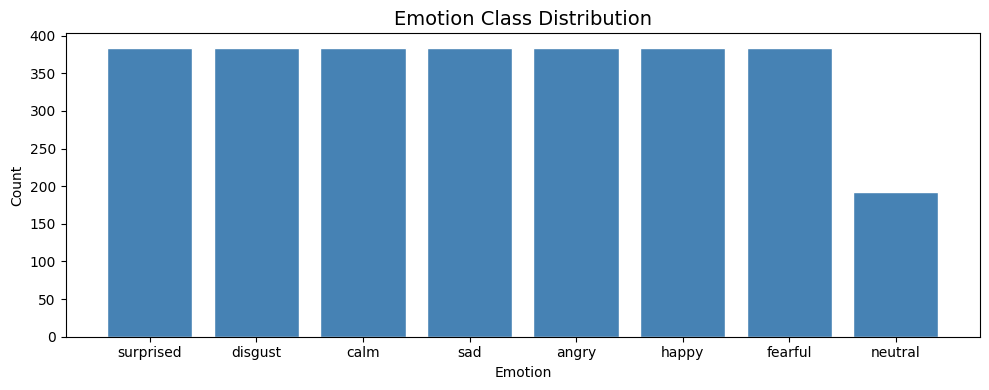

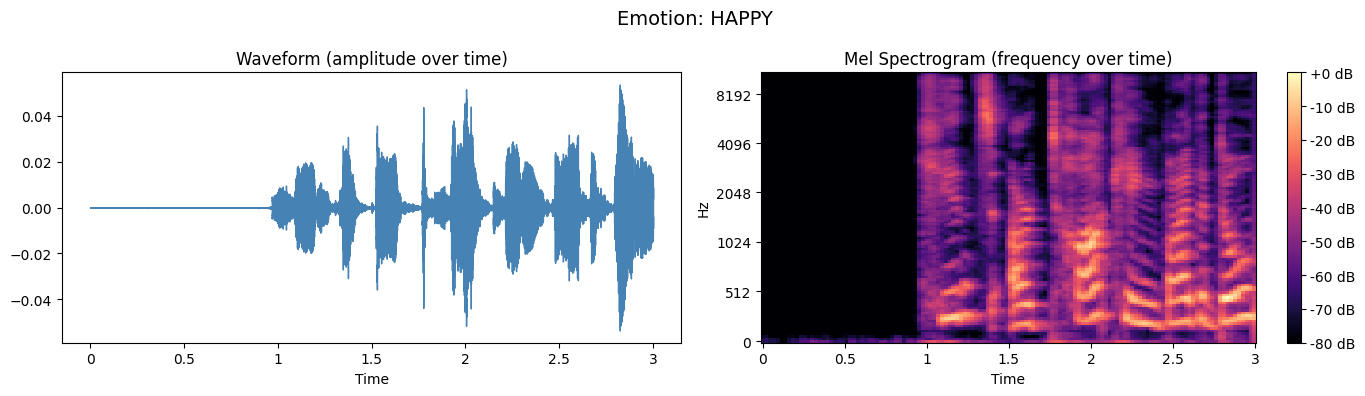

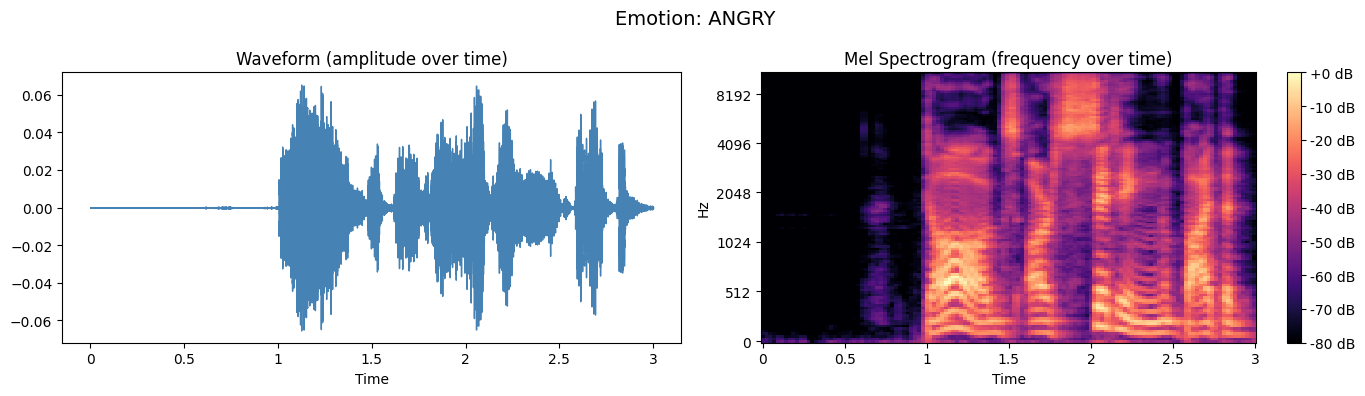

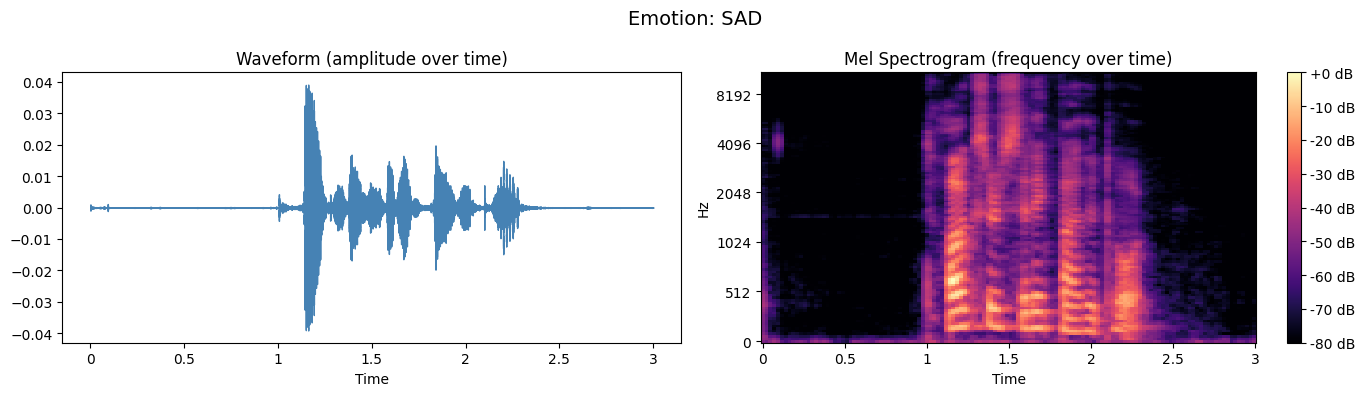

In [35]:
def plot_class_distribution(df: pd.DataFrame):
    """Bar chart of emotion counts — check for class imbalance."""
    fig, ax = plt.subplots(figsize=(10, 4))
    counts = df['emotion'].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title('Emotion Class Distribution', fontsize=14)
    ax.set_xlabel('Emotion'); ax.set_ylabel('Count')
    plt.tight_layout(); plt.show()

def plot_waveform_and_spectrogram(audio_path: str, emotion_label: str):
    """
    Side-by-side: raw waveform + mel spectrogram.
    Great for building intuition about what emotions 'look' like in audio.
    """
    y, sr = librosa.load(audio_path, duration=3, sr=22050)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Emotion: {emotion_label.upper()}', fontsize=14)

    # --- Waveform ---
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
    axes[0].set_title('Waveform (amplitude over time)')

    # --- Mel Spectrogram ---
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db   = librosa.power_to_db(mel_spec, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                                    y_axis='mel', ax=axes[1],
                                    cmap='magma')
    axes[1].set_title('Mel Spectrogram (frequency over time)')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout(); plt.show()

# Plot distribution
plot_class_distribution(df)

# Visualize a few samples — compare different emotions
for emotion in ['happy', 'angry', 'sad']:
    sample = df[df['emotion'] == emotion].iloc[0]
    plot_waveform_and_spectrogram(sample['path'], emotion)

**What you should notice**

**Angry**

High amplitude, rapid energy bursts, wide frequency spread. Loud and intense on the waveform.

**Sad**

Low amplitude, slow pace, concentrated in lower frequencies. Quiet and flat.

**Happy**

Moderate-high amplitude, rhythmic variations, energy spread across mid frequencies.

**Neutral**

Even amplitude, consistent frequency pattern. The baseline all other emotions deviate from.

# **Feature Extraction — MFCCs & Friends**

Converting raw audio into numbers your model can learn from
Raw audio is just a list of numbers (samples). We need to extract meaningful features that capture the characteristics of speech. This is the most important step, garbage features = garbage model, no matter how fancy your neural network.

# **What are MFCCs?**

**MFCC**

Mel-Frequency Cepstral Coefficients. Represent the "shape" of the vocal tract. Mimic how human ears perceive sound. Usually 40 coefficients.

**Chroma**

12 pitch class features. Captures the musical/tonal quality of speech. Useful for differentiating happy vs sad.

**Mel Spectrogram**

A 2D image-like representation of frequency over time, scaled to human hearing. Great for CNNs.

**Zero Crossing Rate**

How often the signal crosses zero. High ZCR = noisy/unvoiced sounds. Helps distinguish emotions.

# **Complete feature extraction function**

In [36]:
def extract_features(audio_path: str,
                       n_mfcc: int = 40,
                       n_chroma: int = 12,
                       n_mels: int = 128,
                       sample_rate: int = 22050,
                       max_duration: float = 3.0) -> np.ndarray:
    """
    Extract a rich feature vector from an audio file.

    Returns a 1D numpy array of shape (180,) combining:
      - 40 MFCCs (mean across time)
      - 40 MFCC delta (1st derivative — captures change)
      - 12 Chroma features
      - 128 Mel spectrogram features
      Total: 220 features
    """
    try:
        # Load audio (trim silence, fix sample rate)
        y, sr = librosa.load(audio_path, sr=sample_rate,
                              duration=max_duration)
        y, _ = librosa.effects.trim(y, top_db=20)  # remove silence

        # --- MFCCs: shape (n_mfcc, time_frames) ---
        mfccs  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_delta = librosa.feature.delta(mfccs)  # velocity

        # --- Chroma features (pitch class) ---
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        # --- Mel Spectrogram ---
        mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # --- Take the mean along the time axis ---
        # This converts each 2D feature into a single number per coefficient
        features = np.concatenate([
            np.mean(mfccs,       axis=1),   # shape: (40,)
            np.mean(mfccs_delta, axis=1),   # shape: (40,)
            np.mean(chroma,      axis=1),   # shape: (12,)
            np.mean(mel_db,      axis=1),   # shape: (128,)
        ])

        return features  # shape: (220,)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Apply to all files (tqdm shows a progress bar)
print("Extracting features — this takes a few minutes...")
features_list, labels_list = [], []

for _, row in tqdm(df.iterrows(), total=len(df)):
    feat = extract_features(row['path'])
    if feat is not None:
        features_list.append(feat)
        labels_list.append(row['emotion'])

X = np.array(features_list)  # shape: (n_samples, 220)
y_labels = np.array(labels_list)
print(f"Feature matrix shape: {X.shape}")

Extracting features — this takes a few minutes...


100%|██████████| 2880/2880 [03:03<00:00, 15.66it/s]

Feature matrix shape: (2880, 220)


# **Data Preprocessing**

Splitting, scaling, encoding, getting data model-ready

Raw features can't go straight into a model. We need to: encode labels (text → numbers), normalize features (same scale = faster convergence), and split the data (never test on training data!).

In [40]:
# ── 1. Encode string labels to integers ───────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
print(f"Classes: {le.classes_}")  # ['angry', 'calm', 'disgust', ...]
NUM_CLASSES = len(le.classes_)

# One-hot encode for categorical crossentropy loss
y_cat = to_categorical(y_encoded, num_classes=NUM_CLASSES)

# ── 2. Train / Validation / Test split ────────────────────────────
# First split off 20% for testing (never touched during training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded  # ensures balanced class distribution in splits
)

# Then split off 15% of training for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42
)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

# ── 3. Scale features (mean=0, std=1) ────────────────────────────
# IMPORTANT: fit ONLY on training data, then transform all splits
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ── 4. Reshape for CNN/LSTM (add channel dimension) ──────────────
# CNNs & LSTMs expect: (batch, timesteps, features)
X_train_r = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_val_r   = X_val_scaled.reshape(-1, X_val_scaled.shape[1], 1)
X_test_r  = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)

print(f"Final input shape: {X_train_r.shape}")
# Expected: (n_train, 220, 1)

# Save scaler and encoder for later use in prediction
import joblib
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le,     'models/label_encoder.pkl')

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Train:      1958 samples
Validation: 346 samples
Test:       576 samples
Final input shape: (1958, 220, 1)


['models/label_encoder.pkl']

# **Building the CNN + LSTM Model**

The deep learning architecture for sequence classification
We combine two powerful architectures: CNN (Conv1D) to extract local patterns from the feature sequence, and LSTM to capture temporal dependencies across the sequence. Together they're excellent for audio data.

**Model architecture flow**

Input
(220, 1)
→
Conv1D
256 filters
→
MaxPool
+ BatchNorm
→
Conv1D
128 filters
→
LSTM
128 units
→
Dense
Softmax

**Full model definition**

In [38]:
def build_cnn_lstm_model(input_shape: tuple,
                           num_classes: int,
                           dropout_rate: float = 0.3) -> tf.keras.Model:
    """
    CNN + LSTM model for emotion classification from speech features.

    Architecture rationale:
    - Conv1D layers detect local patterns (e.g. a stressed syllable)
    - BatchNorm speeds up training + stabilizes gradients
    - LSTM captures sequential patterns across the feature vector
    - Dropout prevents overfitting on our small dataset
    """
    model = Sequential([

        # ── Block 1: Local feature extraction ──
        Conv1D(filters=256, kernel_size=5, padding='same',
               activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # ── Block 2: Higher-level patterns ──
        Conv1D(filters=128, kernel_size=5, padding='same',
               activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # ── Block 3: Sequential context ──
        LSTM(units=128, return_sequences=True),
        Dropout(dropout_rate),

        LSTM(units=64, return_sequences=False),
        Dropout(dropout_rate),

        # ── Classification head ──
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')  # probability per class
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model

# Build the model
INPUT_SHAPE = (X_train_r.shape[1], X_train_r.shape[2])  # (220, 1)
model = build_cnn_lstm_model(INPUT_SHAPE, NUM_CLASSES)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 220, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 220, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 110, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 110, 128)       │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 110, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 55, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 55, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 55, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 55, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,712 (1.35 MB)

 Trainable params: 351,944 (1.34 MB)

 Non-trainable params: 768 (3.00 KB)

**Conv1D**

Slides a filter across the feature sequence to find local patterns, like an edge detector for audio features.

**BatchNorm**

Normalizes layer inputs mid-network. Makes training 2-3x faster and more stable.

**LSTM**

Has memory — can learn that the beginning of an utterance affects how to interpret the end. Great for sequences.

**Dropout**

Randomly disables neurons during training. Forces the network to not over-rely on any one pathway — reduces overfitting.

# **Training the Model**

**Where the magic happens**

Training is the process of adjusting the model's weights so it minimizes prediction error. We use smart callbacks to avoid wasting time, prevent overfitting, and save the best version of the model automatically.

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.1888 - loss: 2.0268
Epoch 1: val_accuracy improved from None to 0.18497, saving model to models/best_model.h5



Epoch 1: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 331ms/step - accuracy: 0.1905 - loss: 2.0179 - val_accuracy: 0.1850 - val_loss: 1.9967 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.2401 - loss: 1.9531
Epoch 2: val_accuracy did not improve from 0.18497
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 542ms/step - accuracy: 0.2288 - loss: 1.9718 - val_accuracy: 0.1474 - val_loss: 2.0464 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.2561 - loss: 1.9460
Epoch 3: val_accuracy did not improve from 0.18497
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 485ms/step - accuracy: 0.2503 - loss: 1.9417 - val_accuracy: 0.1647 - val_loss: 1.9994 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.3010 - loss: 1.8675
Epoch 4: val_accuracy improved from 0.18497 to 0.22543, saving model to models/best_model.h5



Epoch 4: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 46s 572ms/step - accuracy: 0.2875 - loss: 1.8902 - val_accuracy: 0.2254 - val_loss: 1.9681 - learning_rate: 0.0010
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.3143 - loss: 1.8379
Epoch 5: val_accuracy improved from 0.22543 to 0.23699, saving model to models/best_model.h5



Epoch 5: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 35s 473ms/step - accuracy: 0.3105 - loss: 1.8397 - val_accuracy: 0.2370 - val_loss: 1.9318 - learning_rate: 0.0010
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.3290 - loss: 1.7783
Epoch 6: val_accuracy improved from 0.23699 to 0.25723, saving model to models/best_model.h5



Epoch 6: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 27s 437ms/step - accuracy: 0.3437 - loss: 1.7793 - val_accuracy: 0.2572 - val_loss: 1.8487 - learning_rate: 0.0010
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.3513 - loss: 1.6951
Epoch 7: val_accuracy improved from 0.25723 to 0.27746, saving model to models/best_model.h5


...


Epoch 29: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 314ms/step - accuracy: 0.8442 - loss: 0.4582 - val_accuracy: 0.7052 - val_loss: 1.1105 - learning_rate: 0.0010
Epoch 30/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.8534 - loss: 0.4334
Epoch 30: val_accuracy did not improve from 0.70520
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 291ms/step - accuracy: 0.8641 - loss: 0.4266 - val_accuracy: 0.6676 - val_loss: 1.2819 - learning_rate: 0.0010
Epoch 31/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8480 - loss: 0.4277
Epoch 31: val_accuracy did not improve from 0.70520
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 297ms/step - accuracy: 0.8560 - loss: 0.4229 - val_accuracy: 0.6821 - val_loss: 1.1368 - learning_rate: 0.0010
Epoch 32/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.8493 - loss: 0.4232
Epoch 32: val_accuracy did not improve from 0.70520
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step - accuracy: 0.8611 - loss: 0.3985 - val_accuracy: 0.690


Epoch 33: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 282ms/step - accuracy: 0.8953 - loss: 0.3172 - val_accuracy: 0.7370 - val_loss: 1.2076 - learning_rate: 0.0010
Epoch 34/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8878 - loss: 0.3437
Epoch 34: val_accuracy improved from 0.73699 to 0.76012, saving model to models/best_model.h5



Epoch 34: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 300ms/step - accuracy: 0.8933 - loss: 0.3250 - val_accuracy: 0.7601 - val_loss: 1.1155 - learning_rate: 5.0000e-04
Epoch 35/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9203 - loss: 0.2540
Epoch 35: val_accuracy improved from 0.76012 to 0.76301, saving model to models/best_model.h5



Epoch 35: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 281ms/step - accuracy: 0.9249 - loss: 0.2329 - val_accuracy: 0.7630 - val_loss: 1.1418 - learning_rate: 5.0000e-04
Epoch 36/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9236 - loss: 0.2380
Epoch 36: val_accuracy did not improve from 0.76301
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step - accuracy: 0.9224 - loss: 0.2356 - val_accuracy: 0.7572 - val_loss: 1.0938 - learning_rate: 5.0000e-04
Epoch 37/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9433 - loss: 0.1732
Epoch 37: val_accuracy did not improve from 0.76301
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.9428 - loss: 0.1813 - val_accuracy: 0.7630 - val_loss: 1.2109 - learning_rate: 5.0000e-04
Epoch 38/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9400 - loss: 0.2060
Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 38: val_accuracy improved from 0.76301 to 0.77457, sa


Epoch 38: finished saving model to models/best_model.h5
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 309ms/step - accuracy: 0.9418 - loss: 0.1924 - val_accuracy: 0.7746 - val_loss: 1.0873 - learning_rate: 5.0000e-04
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 28.


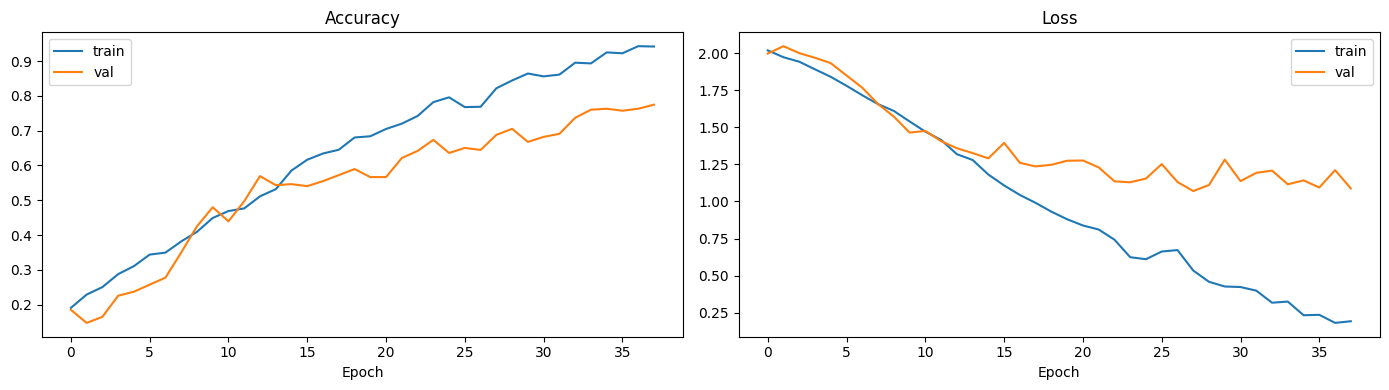

In [39]:
# ── Callbacks — smart training control ─────────────────────────
callbacks = [

    # Stop early if val_loss doesn't improve for 10 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Cut learning rate in half when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Save the model after every improvement
    tf.keras.callbacks.ModelCheckpoint(
        filepath='models/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ── Train! ─────────────────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS     = 100  # EarlyStopping will stop us before this

history = model.fit(
    X_train_r, y_train,
    validation_data=(X_val_r, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ── Plot training curves ────────────────────────────────────────
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['accuracy'],     label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

    ax2.plot(history.history['loss'],     label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

    plt.tight_layout(); plt.show()

plot_history(history)

What to look for in training curves

**Good sign**

Train and val curves both decrease together. Val accuracy eventually stabilizes. The gap between them is small.

**Overfitting**

Train accuracy keeps rising but val accuracy plateaus or drops. Increase dropout, get more data, or add regularization.

**Underfitting**

Both train and val accuracy are low. Try a bigger model, train longer, or extract better features.

**Expected time**

~2-5 min on CPU, ~30 sec on GPU. Early stopping usually kicks in around epoch 30-50.

**Expected Accuracy**

With all 8 emotions expect 65-75% accuracy. With 4 core emotions (happy/sad/angry/neutral) expect 75-85%. Human-level is ~70% on RAVDESS, so 75%+ means you're doing great!

# **Evaluating Model Performance**

**Understanding your results beyond simple accuracy**

Accuracy alone isn't enough. We use a confusion matrix to see which emotions are confused with each other, and a classification report to get precision/recall/F1 per class. This tells us where the model struggles.

Test Accuracy: 0.7917 (79.2%)
Test Loss:     1.0271
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step

── Classification Report ──
              precision    recall  f1-score   support

       angry       0.78      0.82      0.80        76
        calm       0.76      0.79      0.78        77
     disgust       0.86      0.73      0.79        77
     fearful       0.76      0.88      0.82        77
       happy       0.86      0.79      0.82        77
     neutral       0.79      0.71      0.75        38
         sad       0.75      0.79      0.77        77
   surprised       0.78      0.78      0.78        77

    accuracy                           0.79       576
   macro avg       0.79      0.79      0.79       576
weighted avg       0.79      0.79      0.79       576



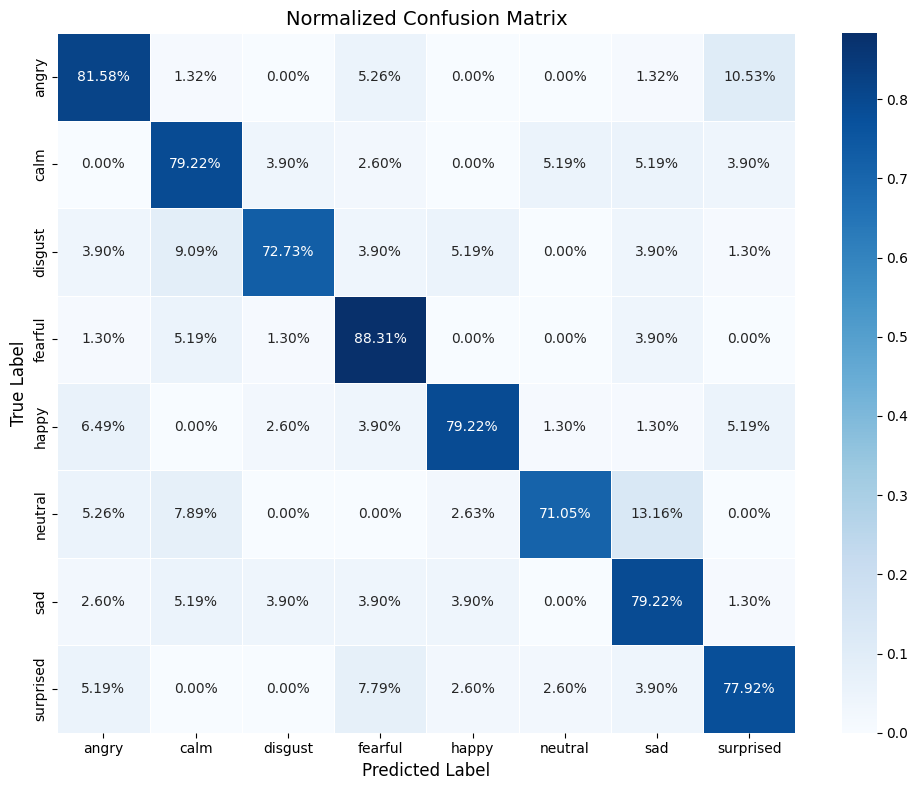

angry       : accuracy=81.58%, avg confidence=77.80%
calm        : accuracy=79.22%, avg confidence=77.18%
disgust     : accuracy=72.73%, avg confidence=71.07%
fearful     : accuracy=88.31%, avg confidence=83.32%
happy       : accuracy=79.22%, avg confidence=74.11%
neutral     : accuracy=71.05%, avg confidence=67.43%
sad         : accuracy=79.22%, avg confidence=72.73%
surprised   : accuracy=77.92%, avg confidence=72.88%


In [41]:
# ── Load best saved model ───────────────────────────────────────
model = tf.keras.models.load_model('models/best_model.h5')

# ── Overall test accuracy ───────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test_r, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Test Loss:     {test_loss:.4f}")

# ── Predictions ─────────────────────────────────────────────────
y_pred_proba = model.predict(X_test_r)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = np.argmax(y_test,       axis=1)

# ── Classification report (per-class F1) ────────────────────────
print("\n── Classification Report ──")
print(classification_report(
    y_true, y_pred,
    target_names=le.classes_
))

# ── Confusion matrix heatmap ─────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    # Normalize to percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5)

    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title('Normalized Confusion Matrix', fontsize=14)
    plt.tight_layout(); plt.show()

plot_confusion_matrix(y_true, y_pred, le.classes_)

# ── Per-class confidence analysis ───────────────────────────────
for i, emotion in enumerate(le.classes_):
    mask    = y_true == i
    correct = (y_pred[mask] == i).mean()
    conf    = y_pred_proba[mask, i].mean()
    print(f"{emotion:12s}: accuracy={correct:.2%}, avg confidence={conf:.2%}")

**Interpreting the confusion matrix**

The diagonal = correct predictions.
Off-diagonal = confusions. Common confusions in speech emotion: calm ↔ neutral (both are low arousal), fearful ↔ surprised (both involve raised pitch), and happy ↔ surprised.

~70%
8 emotions
~80%
4 emotions
~70%
Human level
F1

**Key metric**

Focus on F1-score

In emotion recognition, some emotions appear less often. F1 per class gives a balanced view — look for emotions with low recall (model misses them often) and investigate why.

# **Real-Time Prediction on New Audio**

Deploying your model — the fun part

Now the best part — using your model on a brand new audio file. We wrap everything into a clean prediction pipeline and even add a simple command-line interface.

In [42]:
import joblib

# ── Load everything we need ──────────────────────────────────────
model   = tf.keras.models.load_model('models/best_model.h5')
scaler  = joblib.load('models/scaler.pkl')
encoder = joblib.load('models/label_encoder.pkl')

def predict_emotion(audio_path: str, top_n: int = 3) -> dict:
    """
    Predict the emotion of a speech audio file.

    Args:
        audio_path: path to a .wav file
        top_n: number of top predictions to return

    Returns:
        dict with prediction, confidence, and all probabilities
    """
    # 1. Extract features (same as training)
    features = extract_features(audio_path)
    if features is None:
        raise ValueError(f"Could not process: {audio_path}")

    # 2. Scale using the SAME scaler from training
    features_scaled = scaler.transform(features.reshape(1, -1))

    # 3. Reshape for model input
    features_3d = features_scaled.reshape(1, -1, 1)

    # 4. Predict
    probabilities = model.predict(features_3d, verbose=0)[0]

    # 5. Format results
    emotion_probs  = {
        emotion: float(prob)
        for emotion, prob in zip(encoder.classes_, probabilities)
    }
    sorted_preds   = sorted(emotion_probs.items(),
                              key=lambda x: x[1], reverse=True)

    return {
        'prediction'  : sorted_preds[0][0],
        'confidence'  : sorted_preds[0][1],
        'top_n'       : sorted_preds[:top_n],
        'all_probs'   : emotion_probs
    }

def predict_and_display(audio_path: str):
    """Pretty-print the prediction with a confidence bar."""
    result = predict_emotion(audio_path)

    print(f"\n{'='*40}")
    print(f" File: {os.path.basename(audio_path)}")
    print(f"{'='*40}")
    print(f" Prediction : {result['prediction'].upper()}")
    print(f" Confidence : {result['confidence']:.1%}")
    print(f"\n Top predictions:")
    for emotion, prob in result['top_n']:
        bar = '█' * int(prob * 20) + '░' * (20 - int(prob * 20))
        print(f"  {emotion:12s} {bar} {prob:.1%}")

# Try it on a test sample!
sample_file = df.iloc[0]['path']
predict_and_display(sample_file)

# Try on all test files and show accuracy
print("\n── Testing on 5 random samples ──")
test_samples = df.sample(5)
for _, row in test_samples.iterrows():
    result = predict_emotion(row['path'])
    correct = "✓" if result['prediction'] == row['emotion'] else "✗"
    print(f"{correct} True: {row['emotion']:12s} | Pred: {result['prediction']:12s} | Conf: {result['confidence']:.1%}")


 File: 03-01-08-02-01-02-05.wav
 Prediction : SURPRISED
 Confidence : 98.5%

 Top predictions:
  surprised    ███████████████████░ 98.5%
  angry        ░░░░░░░░░░░░░░░░░░░░ 1.0%
  happy        ░░░░░░░░░░░░░░░░░░░░ 0.2%

── Testing on 5 random samples ──
✓ True: sad          | Pred: sad          | Conf: 99.9%
✗ True: disgust      | Pred: angry        | Conf: 85.0%
✗ True: surprised    | Pred: angry        | Conf: 93.8%
✓ True: neutral      | Pred: neutral      | Conf: 97.6%
✓ True: sad          | Pred: sad          | Conf: 92.4%


**What to explore next**

**Data augmentation**

Add noise, time-stretch, or pitch-shift audio to 3-4x your training data and boost accuracy by 5-10%.

**Transfer learning**

Try wav2vec2 or HuBERT (pre-trained on 1000s of hours of speech). Much better for small datasets.

**Web demo**

Deploy with Gradio or Streamlit — 10 lines of code to get a working web UI with microphone input!

**More datasets**

Combine RAVDESS + TESS + EMO-DB to get 5000+ samples and more diversity. Expect +5-8% accuracy.

**You did it!**

You've built a complete end-to-end speech emotion recognition system — from raw audio files to real predictions. This covers the full ML pipeline: data → features → model → evaluation → deployment.